<a href="https://colab.research.google.com/github/Muhammed-J-gif/Ecommerce-Order-Supply-Chain-Dataset/blob/main/Ecommerce_Order_Supply_Chain_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Environment Setup

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Importing from Google Drive

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# Defining the path to folder in Google Drive
folder_path = '/content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset'

dataframes = {}

# Checking if the folder exists
if os.path.exists(folder_path):
    # List all files in the folder
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df_name = os.path.splitext(file_name)[0]  # Get filename without extension
            print(f'Loading {file_name}...')
            try:
                dataframes[df_name] = pd.read_csv(file_path)
                print(f'Successfully loaded {df_name}. Shape: {dataframes[df_name].shape}')
            except Exception as e:
                print(f'Error loading {file_name}: {e}')
else:
    print(f'Folder not found at: {folder_path}. Please check the path and ensure Google Drive is mounted correctly.')

# Display the first few rows of each loaded DataFrame for verification
for name, df in dataframes.items():
    print(f'\n--- {name}.head() ---')
    display(df.head())

Loading analysis_data_for_powerbi.csv...


/tmp/ipykernel_6024/3891022966.py:15: DtypeWarning: Columns (17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(file_path)


Successfully loaded analysis_data_for_powerbi. Shape: (3012669, 19)

--- analysis_data_for_powerbi.head() ---


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_status,order_delivered_timestamp,order_estimated_delivery_date
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
1,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
2,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
3,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,pending,NaN,NaN
4,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,pending,NaN,NaN


### Loading Data from 'test' and 'train' Subfolders in Google Drive

In [62]:
base_drive_path = '/content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/'

def load_data_from_subfolder(subfolder_name):
    full_subfolder_path = os.path.join(base_drive_path, subfolder_name)
    subfolder_dataframes = {}
    print(f'\n--- Loading data from {full_subfolder_path} ---')

    if os.path.exists(full_subfolder_path):
        for file_name in os.listdir(full_subfolder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(full_subfolder_path, file_name)
                df_name = file_name.replace('df_', '').replace('.csv', '') # e.g., 'Orders', 'Customers'
                print(f'Loading {file_name}...')
                try:
                    subfolder_dataframes[df_name.lower()] = pd.read_csv(file_path)
                    print(f'Successfully loaded {df_name} as \'{df_name.lower()}\' for {subfolder_name}. Shape: {subfolder_dataframes[df_name.lower()].shape}')
                except Exception as e:
                    print(f'Error loading {file_name} from {subfolder_name}: {e}')
    else:
        print(f'Subfolder not found: {full_subfolder_path}. Please check the path.')
    return subfolder_dataframes

# Load data from 'test' folder
test_data = load_data_from_subfolder('test')

# Load data from 'train' folder
train_data = load_data_from_subfolder('train')

print('\nSummary of loaded test dataframes:')
for name, df in test_data.items():
    print(f'{name}: {df.shape}')

print('\nSummary of loaded train dataframes:')
for name, df in train_data.items():
    print(f'{name}: {df.shape}')



--- Loading data from /content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/test ---
Loading df_Payments.csv...
Successfully loaded Payments as 'payments' for test. Shape: (38279, 5)
Loading df_Orders.csv...
Successfully loaded Orders as 'orders' for test. Shape: (38279, 4)
Loading df_Customers.csv...
Successfully loaded Customers as 'customers' for test. Shape: (38279, 4)
Loading df_Products.csv...
Successfully loaded Products as 'products' for test. Shape: (38279, 6)
Loading df_OrderItems.csv...
Successfully loaded OrderItems as 'orderitems' for test. Shape: (38279, 5)

--- Loading data from /content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/train ---
Loading df_Customers.csv...
Successfully loaded Customers as 'customers' for train. Shape: (89316, 4)
Loading df_OrderItems.csv...
Successfully loaded OrderItems as

### Merging and Combining 'test' and 'train' Datasets

In [63]:
# Function to merge dataframes for a given dataset (test or train)
def create_analysis_df(data_dict, prefix):
    if all(key in data_dict for key in ['orders', 'customers', 'orderitems', 'products']):
        merged_df = (
            data_dict['orders']
            .merge(data_dict['customers'], on="customer_id", how="left")
            .merge(data_dict['orderitems'], on="order_id", how="left")
            .merge(data_dict['products'], on="product_id", how="left")
        )
        print(f'Successfully created {prefix}_analysis_df. Shape: {merged_df.shape}')
        return merged_df
    else:
        print(f'Could not create {prefix}_analysis_df. Missing one or more required dataframes (orders, customers, orderitems, products).')
        return pd.DataFrame()

# Create analysis_df for test data
test_analysis_df = create_analysis_df(test_data, 'test')

# Create analysis_df for train data
train_analysis_df = create_analysis_df(train_data, 'train')

# Combine test and train analysis dataframes
if not test_analysis_df.empty and not train_analysis_df.empty:
    combined_analysis_df = pd.concat([test_analysis_df, train_analysis_df], ignore_index=True)
    print(f'\nSuccessfully combined test and train data into combined_analysis_df. Shape: {combined_analysis_df.shape}')
    print('\nCombined Analysis DataFrame Head:')
    display(combined_analysis_df.head())
elif not test_analysis_df.empty:
    combined_analysis_df = test_analysis_df
    print(f'\nOnly test_analysis_df was created. Assigning it to combined_analysis_df. Shape: {combined_analysis_df.shape}')
elif not train_analysis_df.empty:
    combined_analysis_df = train_analysis_df
    print(f'\nOnly train_analysis_df was created. Assigning it to combined_analysis_df. Shape: {combined_analysis_df.shape}')
else:
    combined_analysis_df = pd.DataFrame()
    print('\nNo analysis dataframes could be created or combined.')


Successfully created test_analysis_df. Shape: (483183, 16)
Successfully created train_analysis_df. Shape: (2529486, 19)

Successfully combined test and train data into combined_analysis_df. Shape: (3012669, 19)

Combined Analysis DataFrame Head:


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,...,product_height_cm,product_width_cm,order_status,order_delivered_timestamp,order_estimated_delivery_date
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,...,5.0,11.0,NaN,NaN,NaN
1,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,...,5.0,11.0,NaN,NaN,NaN
2,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,...,5.0,11.0,NaN,NaN,NaN
3,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,...,7.0,14.0,NaN,NaN,NaN
4,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,...,7.0,14.0,NaN,NaN,NaN


## Data Cleaning & Preprocessing on Combined Dataset

Now that we have `combined_analysis_df`, we will apply cleaning and preprocessing steps based on the business requirements gathered.

### 3.1 Data Overview and Missing Values Check

In [64]:
print("Combined DataFrame Info:")
display(combined_analysis_df.info())

print("\nMissing values in combined_analysis_df:")
display(combined_analysis_df.isnull().sum())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   order_id                       object 
 1   customer_id                    object 
 2   order_purchase_timestamp       object 
 3   order_approved_at              object 
 4   customer_zip_code_prefix       int64  
 5   customer_city                  object 
 6   customer_state                 object 
 7   product_id                     object 
 8   seller_id                      object 
 9   price                          float64
 10  shipping_charges               float64
 11  product_category_name          object 
 12  product_weight_g               float64
 13  product_length_cm              float64
 14  product_height_cm              float64
 15  product_width_cm               float64
 16  order_status                   object 
 17  order_delivered_times

None


Missing values in combined_analysis_df:


,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_approved_at,284
customer_zip_code_prefix,0
customer_city,0
customer_state,0
product_id,0
seller_id,0
price,0


### 3.2 Data Type Conversion and Missing Value Imputation

In [65]:
# Convert timestamp columns to datetime objects
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]
for col in timestamp_cols:
    combined_analysis_df[col] = pd.to_datetime(combined_analysis_df[col], errors='coerce')

# Convert customer_zip_code_prefix to object/string as it's a categorical identifier
combined_analysis_df['customer_zip_code_prefix'] = combined_analysis_df['customer_zip_code_prefix'].astype(str)

# Handle missing values

# Fill missing product_category_name with 'Unknown'
combined_analysis_df['product_category_name'] = combined_analysis_df['product_category_name'].fillna('Unknown')

# Impute missing product dimensions with the median
product_dimension_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in product_dimension_cols:
    median_val = combined_analysis_df[col].median()
    combined_analysis_df[col] = combined_analysis_df[col].fillna(median_val)

# For 'order_approved_at', if missing, assume it was approved at the time of purchase
# This aligns with the 'improve order fulfillment efficiency' objective by ensuring a complete timeline.
combined_analysis_df['order_approved_at'] = combined_analysis_df['order_approved_at'].fillna(combined_analysis_df['order_purchase_timestamp'])

# For 'order_status', 'order_delivered_timestamp', and 'order_estimated_delivery_date':
# Missing values here are significant and indicate non-delivered or pending orders.
# We will fill 'order_status' with 'pending' if it's null.
combined_analysis_df['order_status'] = combined_analysis_df['order_status'].fillna('pending')

# For 'order_delivered_timestamp' and 'order_estimated_delivery_date',
# it's best to leave them as NaT (Not a Time) if the order was not delivered.
# This allows for accurate calculation of 'on-time delivery rate' and 'delivery delay duration'
# by clearly distinguishing delivered from non-delivered orders.


print("\nData types after conversion and missing value handling:")
display(combined_analysis_df.info())

print("\nMissing values after handling:")
display(combined_analysis_df.isnull().sum())


Data types after conversion and missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_purchase_timestamp       datetime64[ns]
 3   order_approved_at              datetime64[ns]
 4   customer_zip_code_prefix       object        
 5   customer_city                  object        
 6   customer_state                 object        
 7   product_id                     object        
 8   seller_id                      object        
 9   price                          float64       
 10  shipping_charges               float64       
 11  product_category_name          object        
 12  product_weight_g               float64       
 13  product_length_cm              float64       
 14  product_h

None


Missing values after handling:


,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_approved_at,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
product_id,0
seller_id,0
price,0


## Exploratory Data Analysis (EDA)

### Data Type Conversion

In [66]:
# Convert timestamp columns to datetime objects for time-series analysis
combined_analysis_df['order_purchase_timestamp'] = pd.to_datetime(combined_analysis_df['order_purchase_timestamp'])
combined_analysis_df['order_approved_at'] = pd.to_datetime(combined_analysis_df['order_approved_at'])

print('Data types after conversion:')
display(combined_analysis_df.info())

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_purchase_timestamp       datetime64[ns]
 3   order_approved_at              datetime64[ns]
 4   customer_zip_code_prefix       object        
 5   customer_city                  object        
 6   customer_state                 object        
 7   product_id                     object        
 8   seller_id                      object        
 9   price                          float64       
 10  shipping_charges               float64       
 11  product_category_name          object        
 12  product_weight_g               float64       
 13  product_length_cm              float64       
 14  product_height_cm              float6

None

### Distribution of Key Numerical Features

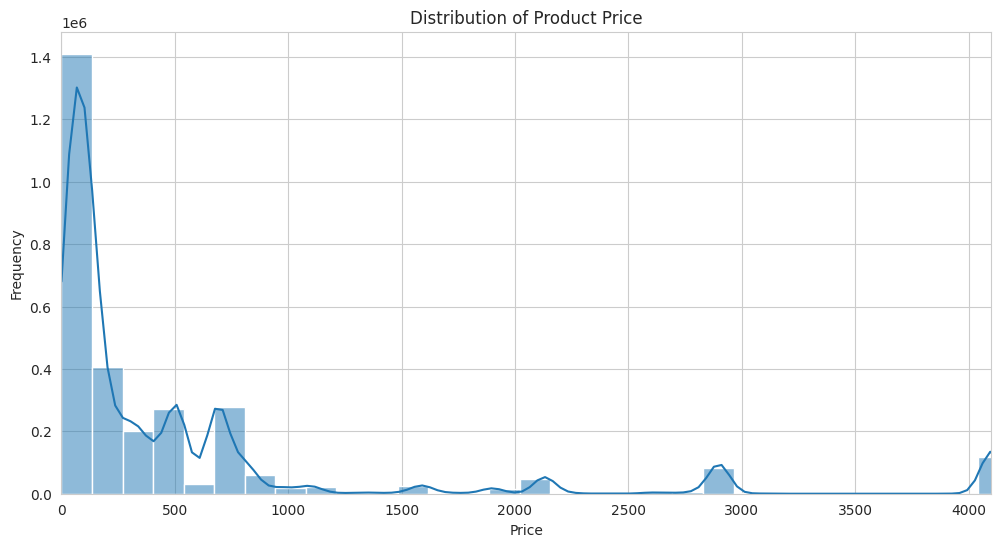

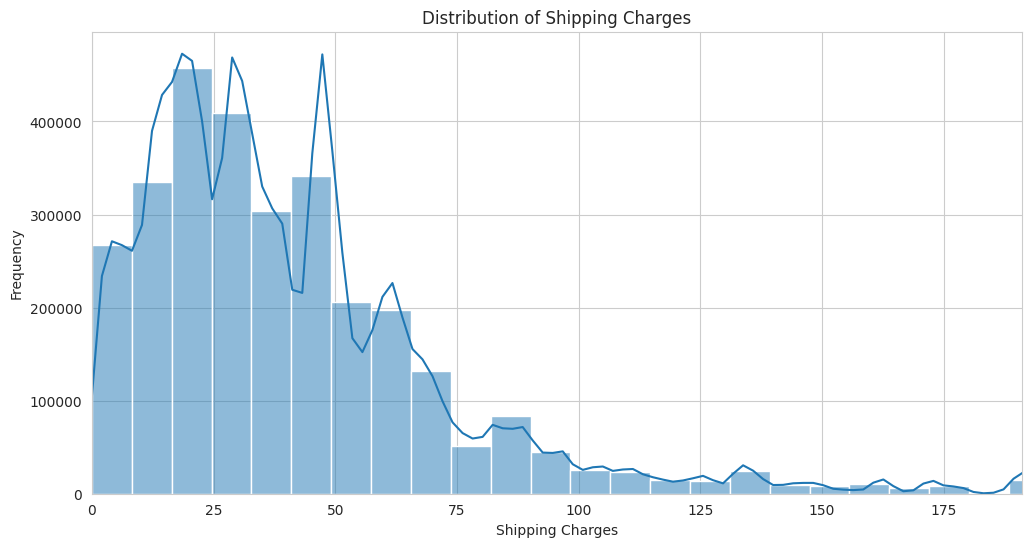

In [67]:
# Set style for plots
sns.set_style('whitegrid')

# Distribution of Price
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['price'], bins=50, kde=True)
plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['price'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.show()

# Distribution of Shipping Charges
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['shipping_charges'], bins=50, kde=True)
plt.title('Distribution of Shipping Charges')
plt.xlabel('Shipping Charges')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['shipping_charges'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.show()

### Distribution of Product Categories

/tmp/ipykernel_6024/881530459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


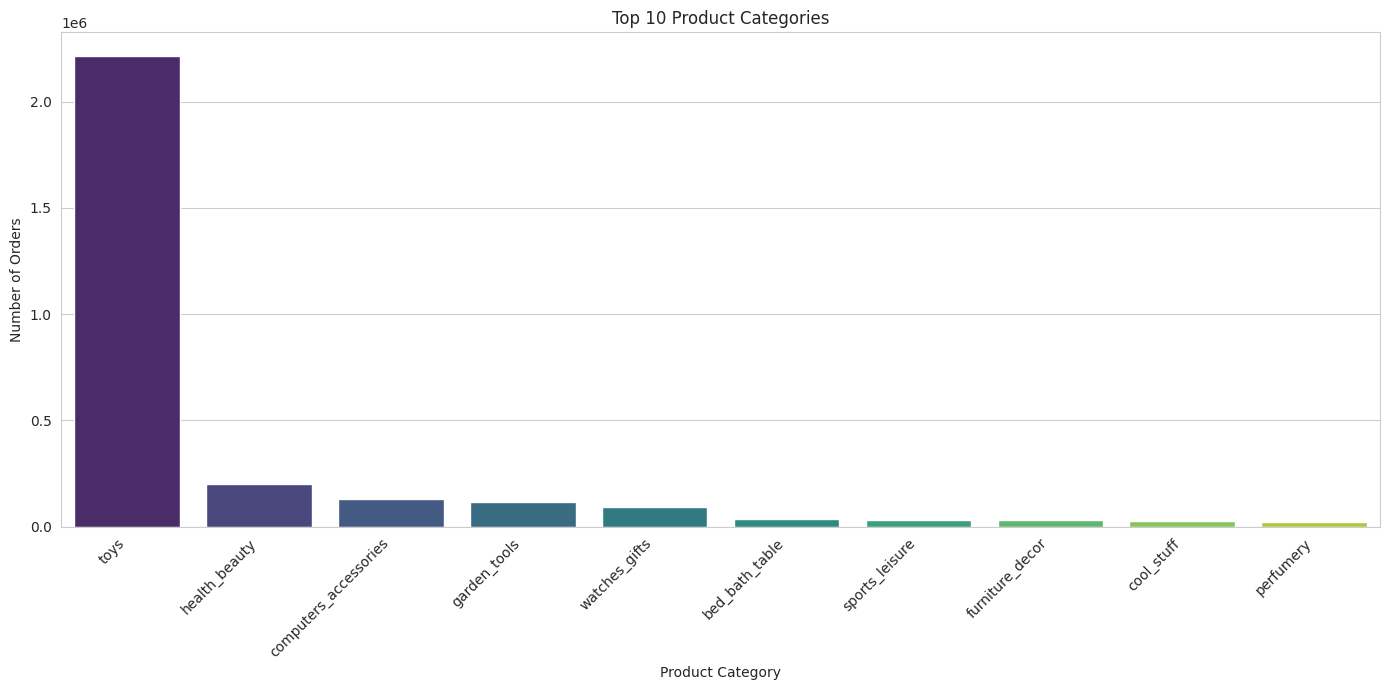

In [68]:
# Fill missing product category names with 'Unknown' for better visualization
combined_analysis_df['product_category_name'] = combined_analysis_df['product_category_name'].fillna('Unknown')

# Top 10 Product Categories
plt.figure(figsize=(14, 7))
top_categories = combined_analysis_df['product_category_name'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Sales Trends Over Time

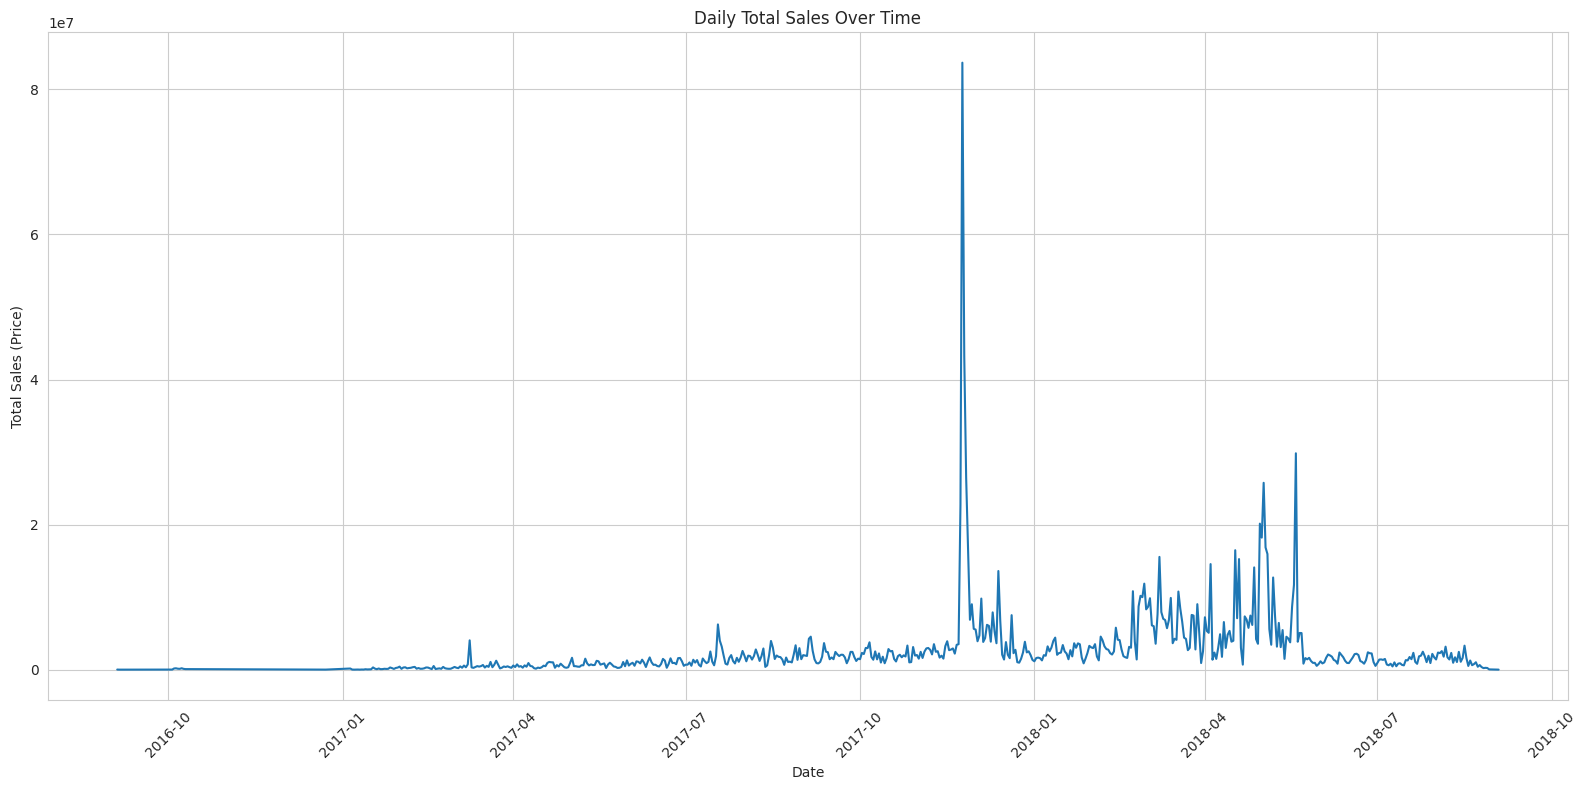

In [69]:
# Aggregate total sales by order purchase timestamp (daily)
daily_sales = combined_analysis_df.groupby(combined_analysis_df['order_purchase_timestamp'].dt.date)['price'].sum().reset_index()
daily_sales['order_purchase_timestamp'] = pd.to_datetime(daily_sales['order_purchase_timestamp'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_timestamp', y='price', data=daily_sales)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Price)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Order Volume

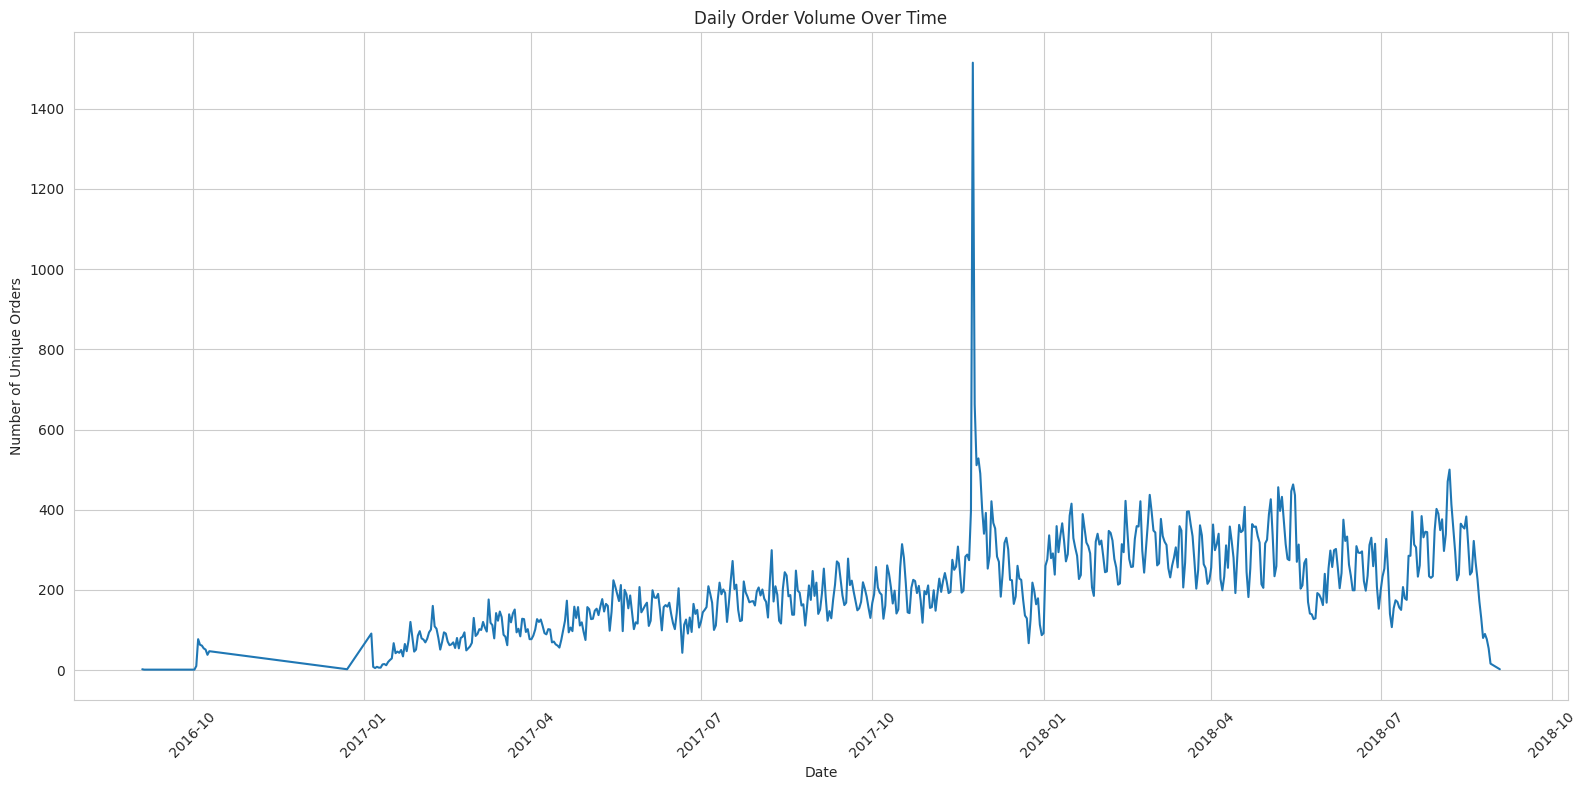

In [70]:
# Aggregate daily order volume
daily_order_volume = combined_analysis_df.groupby(combined_analysis_df['order_purchase_timestamp'].dt.date)['order_id'].nunique().reset_index()
daily_order_volume['order_purchase_timestamp'] = pd.to_datetime(daily_order_volume['order_purchase_timestamp'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_timestamp', y='order_id', data=daily_order_volume)
plt.title('Daily Order Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Unique Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Real-time Delivery Status Analysis

To understand the delivery performance, calculation on several time-related metrics and visualize the distribution of order statuses and delivery outcomes was done to produce the results needed

In [86]:
# Calculate Delivery Lead Time (Time from purchase to actual delivery)
# Only for delivered orders, otherwise it will be NaT
combined_analysis_df['delivery_lead_time'] = (combined_analysis_df['order_delivered_timestamp'] - combined_analysis_df['order_purchase_timestamp']).dt.days

# Calculate Delivery Delay (Actual delivery vs. Estimated delivery)
# Positive values mean delayed, negative values mean delivered early
combined_analysis_df['delivery_delay'] = (combined_analysis_df['order_delivered_timestamp'] - combined_analysis_df['order_estimated_delivery_date']).dt.days

# Create a categorical variable for on-time delivery
combined_analysis_df['on_time_delivery'] = combined_analysis_df['delivery_delay'].apply(lambda x: 'Delayed'
    if x > 0
    else ('On-time/Early' if x <= 0 and pd.notna(x) else 'Not Delivered/Pending'))

print("New delivery-related features created:")
display(combined_analysis_df[['order_purchase_timestamp', 'order_delivered_timestamp', 'order_estimated_delivery_date', 'delivery_lead_time', 'delivery_delay', 'on_time_delivery']].head(-10))

New delivery-related features created:


,order_purchase_timestamp,order_delivered_timestamp,order_estimated_delivery_date,delivery_lead_time,delivery_delay,on_time_delivery
0,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
1,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
2,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
3,2018-06-02 17:13:12,NaT,NaT,NaN,NaN,Not Delivered/Pending
4,2018-06-02 17:13:12,NaT,NaT,NaN,NaN,Not Delivered/Pending
...,...,...,...,...,...,...
3012654,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012655,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012656,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012657,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early


#### Distribution of Order Statuses

/tmp/ipykernel_6024/600305979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='order_status', data=combined_analysis_df, order=combined_analysis_df['order_status'].value_counts().index, palette='viridis')


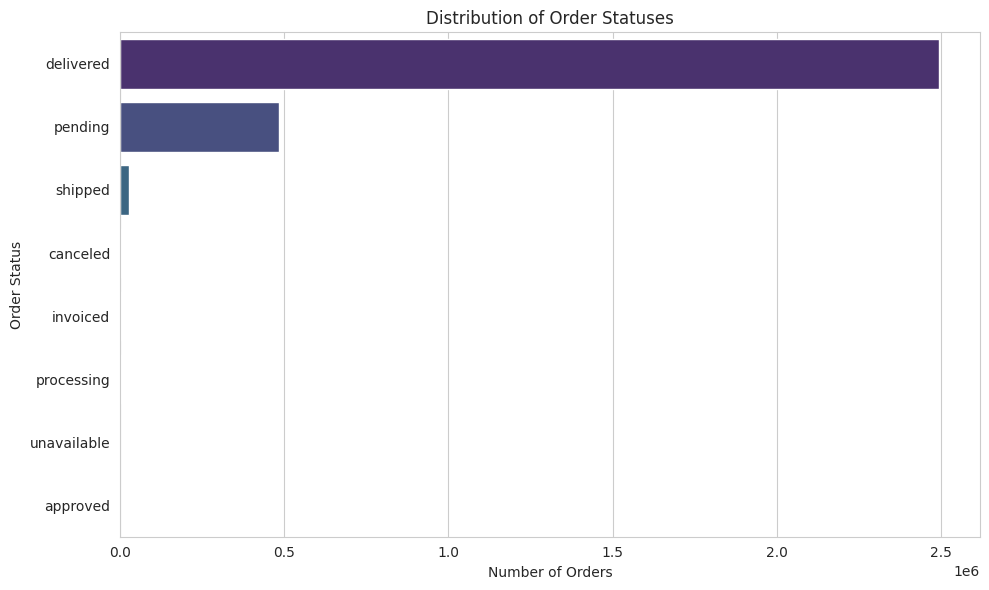

In [87]:
plt.figure(figsize=(10, 6))
sns.countplot(y='order_status', data=combined_analysis_df, order=combined_analysis_df['order_status'].value_counts().index, palette='viridis')
plt.title('Distribution of Order Statuses')
plt.xlabel('Number of Orders')
plt.ylabel('Order Status')
plt.tight_layout()
plt.show()

#### Distribution of Delivery Lead Time

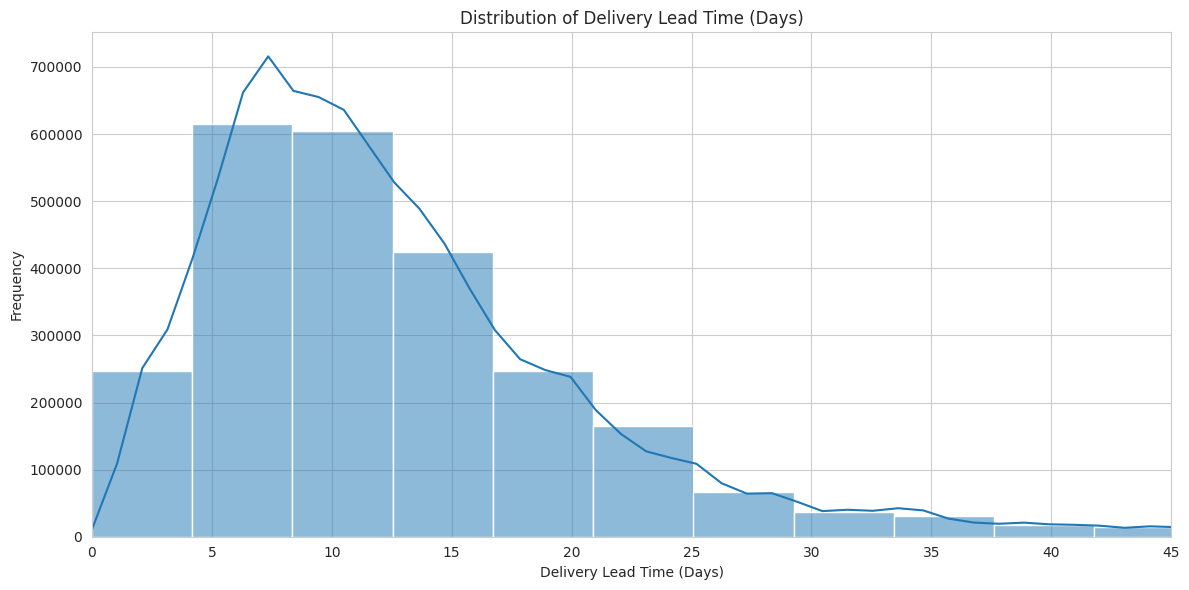

In [88]:
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['delivery_lead_time'].dropna(), bins=50, kde=True)
plt.title('Distribution of Delivery Lead Time (Days)')
plt.xlabel('Delivery Lead Time (Days)')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['delivery_lead_time'].quantile(0.99)) # Limit x-axis to 99th percentile
plt.tight_layout()
plt.show()

#### On-time Delivery Rate

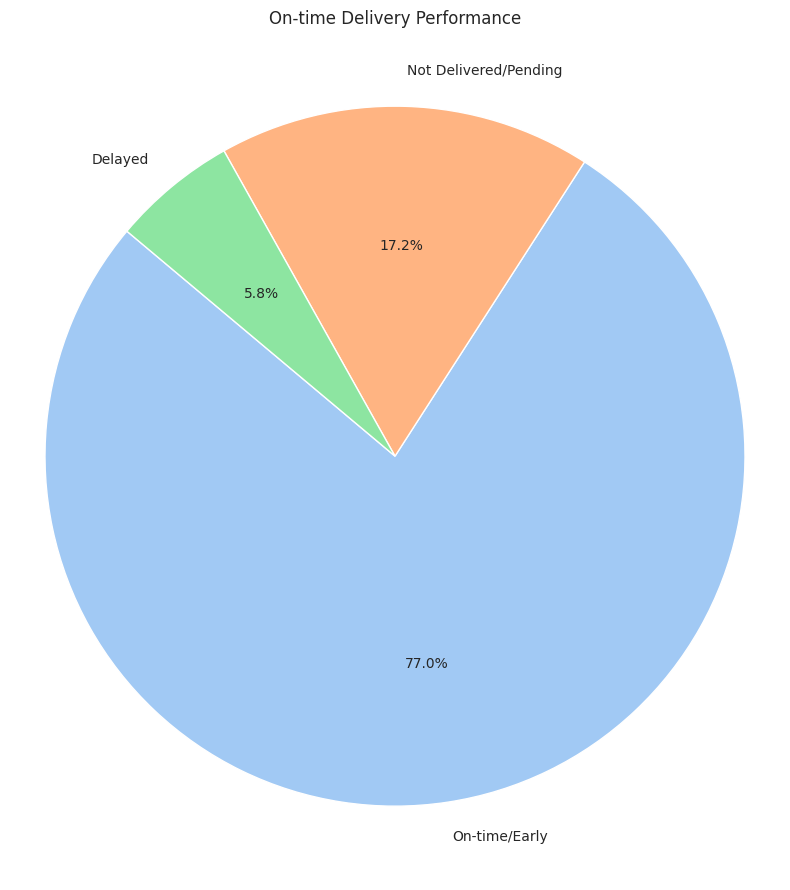

In [89]:
on_time_delivery_counts = combined_analysis_df['on_time_delivery'].value_counts(normalize=True).mul(100).reset_index()
on_time_delivery_counts.columns = ['Delivery Status', 'Percentage']

plt.figure(figsize=(8, 9))
plt.pie(on_time_delivery_counts['Percentage'], labels=on_time_delivery_counts['Delivery Status'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('On-time Delivery Performance')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## Key Business Measures Calculation

### Total Revenue

In [76]:
# Calculate Total Revenue (price + shipping charges) per order item
combined_analysis_df['total_revenue'] = combined_analysis_df['price'] + combined_analysis_df['shipping_charges']

print("Total Revenue column added to combined_analysis_df:")
display(combined_analysis_df[['order_id', 'price', 'shipping_charges', 'total_revenue']].head())

Total Revenue column added to combined_analysis_df:


,order_id,price,shipping_charges,total_revenue
0,u6rPMRAYIGig,24.10,20.90,45.00
1,u6rPMRAYIGig,24.10,20.90,45.00
2,u6rPMRAYIGig,24.10,20.90,45.00
3,ohY8f4FEbX19,42.89,12.28,55.17
4,ohY8f4FEbX19,42.89,12.28,55.17


### Average Order Value (AOV)

In [77]:
# Calculate Average Order Value (Total Revenue ÷ Number of Orders)
# First, calculate total revenue per unique order
revenue_per_order = combined_analysis_df.groupby('order_id')['total_revenue'].sum().reset_index()

aov = revenue_per_order['total_revenue'].mean()

print(f"Average Order Value (AOV): ${aov:,.2f}")

Average Order Value (AOV): $13,845.84


### On-time Delivery Rate

In [78]:
# On-time delivery rate has already been calculated in the 'on_time_delivery_counts' DataFrame
# We can extract the 'On-time/Early' percentage.

on_time_percentage = on_time_delivery_counts[on_time_delivery_counts['Delivery Status'] == 'On-time/Early']['Percentage'].iloc[0]

print(f"On-time Delivery Rate: {on_time_percentage:.2f}%")

On-time Delivery Rate: 77.00%


### Customer Lifetime Value (CLV)

In [79]:
# Calculate Customer Lifetime Value (CLV = Total Revenue per Customer)
clv_per_customer = combined_analysis_df.groupby('customer_id')['total_revenue'].sum().reset_index()
clv_per_customer.rename(columns={'total_revenue': 'customer_lifetime_value'}, inplace=True)

print("Top 10 Customers by CLV:")
display(clv_per_customer.sort_values(by='customer_lifetime_value', ascending=False).head(10))

Top 10 Customers by CLV:


,customer_id,customer_lifetime_value
91389,iXo3TsSEqJUj,1618190.32
12385,64cF8eKRwCzv,1618190.32
56478,RdIqpewtj5wL,1614034.77
116917,urQhymkpjw5b,1614034.77
8509,4APqQ2Wdl7cU,1614034.77
90851,iH6EXp6pYkxV,1614034.77
82330,eDX2NAk8RJvG,1603854.63
9266,4X4KBG3YnsgQ,1599695.25
47701,NMfQkUiFYfIg,1599695.25
125566,z2rmeYNL4iA1,1599695.25


### Payment Success Rate

In [80]:
# Combine test and train payments dataframes
all_payments_df = pd.concat([test_data['payments'], train_data['payments']], ignore_index=True)

# Count unique orders with recorded payments (assuming these are successful)
successful_payments_count = all_payments_df['order_id'].nunique()

# Count total unique orders from the combined analysis dataframe
total_orders_count = combined_analysis_df['order_id'].nunique()

# Calculate Payment Success Rate
payment_success_rate = (successful_payments_count / total_orders_count) * 100

print(f"Number of Unique Orders with Recorded Payments: {successful_payments_count}")
print(f"Total Unique Orders: {total_orders_count}")
print(f"Payment Success Rate: {payment_success_rate:.2f}%")

Number of Unique Orders with Recorded Payments: 127595
Total Unique Orders: 127595
Payment Success Rate: 100.00%


### Category-level Sales

In [84]:
# Calculate total sales per product category
category_sales = combined_analysis_df.groupby('product_category_name')['total_revenue'].sum().reset_index()
category_sales.rename(columns={'total_revenue': 'total_category_sales'}, inplace=True)

print("Top 10 Product Categories by Sales:")
display(category_sales.sort_values(by='total_category_sales', ascending=False).head(10))

Top 10 Product Categories by Sales:


,product_category_name,total_category_sales
69,toys,1.392003e+09
42,garden_tools,1.916636e+08
43,health_beauty,3.830603e+07
15,computers_accessories,2.997965e+07
70,watches_gifts,2.865278e+07
68,telephony,1.634679e+07
39,furniture_decor,1.194894e+07
8,bed_bath_table,1.014678e+07
65,sports_leisure,8.299562e+06
20,cool_stuff,6.076554e+06


### Ensuring dataframe is intacted holding the ideal data

In [85]:
combined_analysis_df.head(10)

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,...,product_length_cm,product_height_cm,product_width_cm,order_status,order_delivered_timestamp,order_estimated_delivery_date,delivery_lead_time,delivery_delay,on_time_delivery,total_revenue
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,...,16.0,5.0,11.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,45.00
1,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,...,16.0,5.0,11.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,45.00
2,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,...,16.0,5.0,11.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,45.00
3,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,...,21.0,7.0,14.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,55.17
4,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,...,21.0,7.0,14.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,55.17
5,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,...,100.0,5.0,20.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,117.32
6,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,...,100.0,5.0,20.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,117.32
7,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,...,100.0,5.0,20.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,117.32
8,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,...,40.0,30.0,40.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,151.15
9,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,...,40.0,30.0,40.0,pending,NaT,NaT,NaN,NaN,Not Delivered/Pending,151.15


##   Exporting Data for PowerBI

In [75]:
# Define the output file path
output_csv_path = 'analysis_data_for_powerbi.csv'

# Export the analysis_df to a CSV file
combined_analysis_df.to_csv(output_csv_path, index=False)

print(f"Data successfully exported to '{output_csv_path}'")
print("You can now download this file from the file browser in the left panel of Colab or by running the following code:")
print("from google.colab import files")
print(f"files.download('{output_csv_path}')")

Data successfully exported to 'analysis_data_for_powerbi.csv'
You can now download this file from the file browser in the left panel of Colab or by running the following code:
from google.colab import files
files.download('analysis_data_for_powerbi.csv')
